# Missing Data Handling | Titanic Dataset

**Content:**

1. Imports and Data Loading
2. Handling missing data (Cabin deletion, Embarked row deletion, KNN Age imputation, Fare imputation)
3. Save cleaned data


## 1. Imports and Data Loading

In [1]:
import pandas as pd

from titanic_ml.data_loader import load_data, validate_schema

In [2]:
# Load train data
train_raw = load_data("../data/train.csv")
validate_schema(train_raw, is_training=True)
print(f"Training set: {train_raw.shape[0]} rows, {train_raw.shape[1]} columns")
print("=== Training set missing values ===")
print(train_raw.isnull().sum()[train_raw.isnull().sum() > 0])
display(train_raw.head())

# Load test data
test_raw = load_data("../data/test.csv")
validate_schema(test_raw, is_training=False)
print(f"Test set:     {test_raw.shape[0]} rows, {test_raw.shape[1]} columns")
print("=== Test set missing values ===")
print(test_raw.isnull().sum()[test_raw.isnull().sum() > 0])
display(test_raw.head())

Training set: 891 rows, 12 columns
=== Training set missing values ===
Age         177
Cabin       687
Embarked      2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Test set:     418 rows, 11 columns
=== Test set missing values ===
Age       86
Fare       1
Cabin    327
dtype: int64


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 2. Handling missing data

### 2.1 Column deletion — Cabin

Cabin has ~77% missing values, any imputation would be filling the majority of
the column with guesses. Hence, I'll delete the column (losing one feature) to preserve all 891 rows.

In [3]:
# Column deletion: drop Cabin from both sets (~77% missing)
print(f"Cabin missing rate — train: {train_raw['Cabin'].isnull().mean():.1%}, test: {test_raw['Cabin'].isnull().mean():.1%}")

train_raw = train_raw.drop(columns=["Cabin"])
test_raw = test_raw.drop(columns=["Cabin"])

print(f"\nAfter dropping Cabin:")
print(f"  Train columns: {train_raw.shape[1]}, remaining missing:")
print(train_raw.isnull().sum()[train_raw.isnull().sum() > 0].to_string())
print(f"  Test columns:  {test_raw.shape[1]}, remaining missing:")
print(test_raw.isnull().sum()[test_raw.isnull().sum() > 0].to_string())

Cabin missing rate — train: 77.1%, test: 78.2%

After dropping Cabin:
  Train columns: 11, remaining missing:
Age         177
Embarked      2
  Test columns:  10, remaining missing:
Age     86
Fare     1


### 2.2 Row deletion — Embarked (2 rows)

Only 2 out of 891 training rows are missing `Embarked` (~0.2%), deletion is safe: it won't introduce bias and the data loss is negligible.

Note: We could also impute with the mode (`S`), but deletion is cleaner since no assumption is needed.

In [4]:
# Row deletion: drop the 2 rows with missing Embarked
rows_before = len(train_raw)
train_raw = train_raw.dropna(subset=["Embarked"])
rows_after = len(train_raw)

print(f"Dropped {rows_before - rows_after} rows with missing Embarked")
print(f"\nAfter dropping Embarked:")
print(f"  Train columns: {train_raw.shape[1]}, remaining missing:")
print(train_raw.isnull().sum()[train_raw.isnull().sum() > 0].to_string())
print(f"  Test columns:  {test_raw.shape[1]}, remaining missing:")
print(test_raw.isnull().sum()[test_raw.isnull().sum() > 0].to_string())

Dropped 2 rows with missing Embarked

After dropping Embarked:
  Train columns: 11, remaining missing:
Age    177
  Test columns:  10, remaining missing:
Age     86
Fare     1


### 2.3 KNN imputation — Age (~20% missing)

Age has ~20% missing values, which is too much to delete. We impute it using **K-Nearest Neighbours (KNN)**. 

Notes: 
- We could have also used grouped median (simpler, but creates spikes in the distribution) or tree based regression algorithms such as random forest (capture non linear interactions, but adds complexity)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Extract Title from Name ---
# As explored in notebook 01 (EDA), names follow "LastName, Title. FirstName"
train_raw['Title'] = train_raw['Name'].apply(lambda n: n.split(',')[1].split('.')[0].strip())
test_raw['Title'] = test_raw['Name'].apply(lambda n: n.split(',')[1].split('.')[0].strip())

# --- Normalize titles (same grouping as discovered in notebook 01 EDA) ---
# Equivalents: Mlle/Ms → Miss, Mme → Mrs
# Keep: Mr, Miss, Mrs, Master, Dr, Rev. Everything else → Other
equiv_map = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
keep_titles = {'Mr', 'Miss', 'Mrs', 'Master', 'Dr', 'Rev'}

def normalize_title(title):
    title = equiv_map.get(title, title)
    return title if title in keep_titles else 'Other'

train_raw['Title'] = train_raw['Title'].apply(normalize_title)
test_raw['Title'] = test_raw['Title'].apply(normalize_title)

print('After normalization — training set:')
print(train_raw['Title'].value_counts())

After normalization — training set:
Title
Mr        517
Miss      184
Mrs       125
Master     40
Other      10
Dr          7
Rev         6
Name: count, dtype: int64


In [6]:
# Save original Age for before/after comparison
age_original = train_raw["Age"].copy()

In [7]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Features: Pclass, Sex (encoded), SibSp, Parch, Fare, Title (encoded)
# Fit on combined train+test — no target leakage since only features are used.

knn_features = ["Pclass", "Sex", "SibSp", "Parch", "Fare", "Title"]

# Encode categoricals for KNN (needs numeric input)
le_sex = LabelEncoder().fit(pd.concat([train_raw["Sex"], test_raw["Sex"]]))
le_title = LabelEncoder().fit(pd.concat([train_raw["Title"], test_raw["Title"]]))

def prepare_knn_input(df):
    """Build numeric matrix with Age as last column for KNN imputation."""
    out = df[knn_features].copy()
    out["Sex"] = le_sex.transform(df["Sex"])
    out["Title"] = le_title.transform(df["Title"])
    out["Age"] = df["Age"]
    return out

age_before_train = train_raw["Age"].isnull().sum()
age_before_test = test_raw["Age"].isnull().sum()

# Fit KNN on combined train+test (no target leakage — only features used)
train_knn = prepare_knn_input(train_raw)
test_knn = prepare_knn_input(test_raw)
combined = pd.concat([train_knn, test_knn], ignore_index=True)

# Scale features before KNN so that Fare (0–512) doesn't dominate the Euclidean distance over smaller-range features like Pclass (1–3).
# NaN values in Age are left as-is by the scaler (sklearn ignores NaNs).
scaler = StandardScaler()
combined_scaled = pd.DataFrame(
    scaler.fit_transform(combined),
    columns=combined.columns,
    index=combined.index,
)

knn = KNNImputer(n_neighbors=5)
combined_imputed = pd.DataFrame(
    knn.fit_transform(combined_scaled),
    columns=combined.columns,
    index=combined.index,
)

# Inverse-transform to recover original scale
combined_original = pd.DataFrame(
    scaler.inverse_transform(combined_imputed),
    columns=combined.columns,
    index=combined.index,
)

train_raw["Age"] = combined_original["Age"].values[:len(train_knn)]
test_raw["Age"] = combined_original["Age"].values[len(train_knn):]

print(f"KNN imputation (k=5, features: {knn_features}):")
print(f"  Train: {age_before_train} missing → {train_raw['Age'].isnull().sum()} missing")
print(f"  Test:  {age_before_test} missing → {test_raw['Age'].isnull().sum()} missing")

KNN imputation (k=5, features: ['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Title']):
  Train: 177 missing → 0 missing
  Test:  86 missing → 0 missing


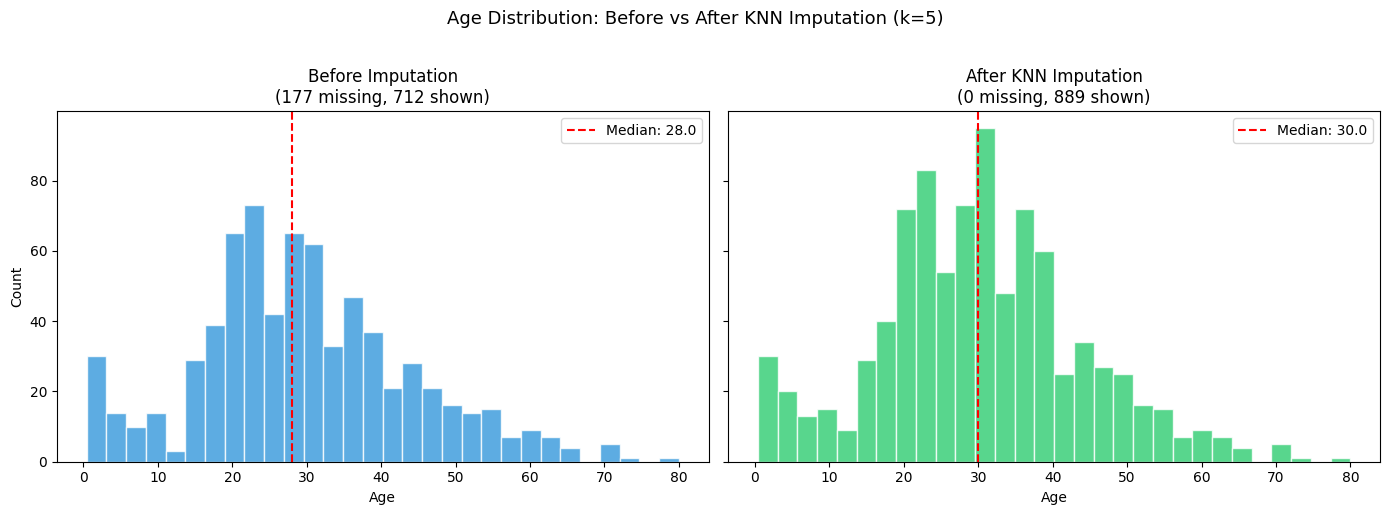

In [8]:
# --- Compare Age distribution before vs after imputation ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Before imputation (original Age, NaN excluded)
axes[0].hist(age_original.dropna(), bins=30, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].axvline(age_original.median(), color="red", linestyle="--", lw=1.5,
                label=f"Median: {age_original.median():.1f}")
axes[0].set_title(f"Before Imputation\n({age_before_train} missing, {len(age_original.dropna())} shown)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend()

# After KNN imputation (all values present)
axes[1].hist(train_raw["Age"], bins=30, color="#2ecc71", edgecolor="white", alpha=0.8)
axes[1].axvline(train_raw["Age"].median(), color="red", linestyle="--", lw=1.5,
                label=f"Median: {train_raw['Age'].median():.1f}")
axes[1].set_title(f"After KNN Imputation\n(0 missing, {len(train_raw)} shown)")
axes[1].set_xlabel("Age")
axes[1].legend()

fig.suptitle("Age Distribution: Before vs After KNN Imputation (k=5)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
print(f"\nAfter imputing Age:")
print(f"  Train columns: {train_raw.shape[1]}, remaining missing:")
print(train_raw.isnull().sum()[train_raw.isnull().sum() > 0].to_string())
print(f"  Test columns:  {test_raw.shape[1]}, remaining missing:")
print(test_raw.isnull().sum()[test_raw.isnull().sum() > 0].to_string())


After imputing Age:
  Train columns: 12, remaining missing:
Series([], )
  Test columns:  11, remaining missing:
Fare    1


### 2.4 Missing value simple imputation — Fare

`Fare` is rarely missing (typically 1 row in the test set), but when it is, we impute
using the **median fare for the passenger's Pclass**. This accounts for the strong
relationship between ticket class and fare.

In [10]:
# Impute Fare by Pclass median (train-only fit is fine here:
# only ~1 test row is missing, and Fare medians are stable across the full dataset)
fare_medians = train_raw.groupby("Pclass")["Fare"].median()
print("Fare medians by Pclass (training set):")
print(fare_medians)

# Only test set has missing Fare — impute using training medians
for pclass, median_val in fare_medians.items():
    mask = test_raw["Fare"].isna() & (test_raw["Pclass"] == pclass)
    test_raw.loc[mask, "Fare"] = median_val

print(f"\nFare missing after imputation — train: {train_raw['Fare'].isnull().sum()}, test: {test_raw['Fare'].isnull().sum()}")

Fare medians by Pclass (training set):
Pclass
1    58.6896
2    14.2500
3     8.0500
Name: Fare, dtype: float64

Fare missing after imputation — train: 0, test: 0


In [11]:
print(f"\nAfter imputing Fare:")
print(f"  Train columns: {train_raw.shape[1]}, remaining missing:")
print(train_raw.isnull().sum()[train_raw.isnull().sum() > 0].to_string())
print(f"  Test columns:  {test_raw.shape[1]}, remaining missing:")
print(test_raw.isnull().sum()[test_raw.isnull().sum() > 0].to_string())


After imputing Fare:
  Train columns: 12, remaining missing:
Series([], )
  Test columns:  11, remaining missing:
Series([], )


In [12]:
# Final validation: ensure no missing values remain in key columns
key_cols = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

for name, df in [("Train", train_raw), ("Test", test_raw)]:
    missing = df[key_cols].isnull().sum()
    missing = missing[missing > 0]
    assert len(missing) == 0, f"{name} still has missing values:\n{missing}"

print("All key columns have zero missing values in both train and test.")

All key columns have zero missing values in both train and test.


## 3. Save Cleaned Data

Save the cleaned DataFrames so the feature engineering notebook can pick up from here.

Note: The `Title` column (extracted for KNN imputation) is intentionally kept as it will be reused during feature engineering.

In [13]:
# Save cleaned data for downstream notebooks
train_raw.to_csv("../data/train_cleaned.csv", index=False)
test_raw.to_csv("../data/test_cleaned.csv", index=False)

print(f"Saved train_cleaned.csv: {train_raw.shape}")
print(f"Saved test_cleaned.csv:  {test_raw.shape}")

Saved train_cleaned.csv: (889, 12)
Saved test_cleaned.csv:  (418, 11)
